# Clustering analysis

In [1]:
import joblib
import os
import time

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from anomaly.utils import get_sdss_spec_img
from anomaly.constants import SDSS_NEBULAR_LINES_RATIOS_NAMES
from astroExplain.spectra import clustering
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Data igestion

In [2]:
def load_xai(run_id: str, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_arr = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")
    weights = np.load(f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r")
    return anomalies_arr, specobjids_arr, weights

In [3]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "norm_unique_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["norm_unique_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_weights"]
    )

    return data_dict

## Averages in clusters

In [4]:
def plot_averages_clusters(
    spectra_cluster_dict,
    weights_cluster_dict,
    wave,
):

    n_clusters = len(spectra_cluster_dict)

    fig, axs = plt.subplots(
        nrows=n_clusters,
        ncols=2,
        figsize=None,
        sharex=True,
        sharey=False,
        tight_layout=True,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    #  weights of centroid

    for label, cluster_weights in weights_cluster_dict.items():

        avg_weights = cluster_weights.mean(axis=0)
        avg_weights /= np.max(avg_weights)

        avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

        axs[label, 0].plot(
            wave,
            avg_spectrum,
            color="black",
        )
        # weights
        axs[label, 1].plot(wave, avg_weights, color="black", label=f"Cluster {label}")

        axs[label, 1].legend(
            [f"Cluster {label}"],
            fontsize=6,
            handlelength=0,
            handletextpad=0,
            loc="upper right",
            frameon=False,
        )
        # set limits
        axs[label, 1].set_ylim(0, 1.1)

    axs[n_clusters - 1, 0].set_xlabel(r"$\lambda$ [nm]")
    axs[n_clusters - 1, 1].set_xlabel(r"$\lambda$ [nm]")

    return fig, axs

## Top ranked explanations

In [5]:
def plot_top_ranked_explanations(
    metadata_df,
    spectra,
    norm_weights,
    wave,
    kmeans_model_dir,
    cluster_id,
    donwload_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
):
    lw = 0.75
    n_anomalies_in_cluster = metadata_df.shape[0]
    print(f"Number of anomalies in cluster {cluster_id}: {n_anomalies_in_cluster}")

    for anomaly_rank in range(0, n_anomalies_in_cluster):
        print(f"Explanation for anomaly rank {anomaly_rank + 1}")
        if anomaly_rank == n_top_ranked:
            break

        anomaly_idx = n_anomalies_in_cluster - 1 - anomaly_rank
        specobjid = metadata_df.index[anomaly_idx]

        if donwload_images is True:
            os.makedirs(f"{kmeans_model_dir}/cluster_{cluster_id}", exist_ok=True)

            # check if the image already exists
            image_path = (
                f"{kmeans_model_dir}/cluster_{cluster_id}/image_{specobjid}.jpeg"
            )

            if not os.path.exists(image_path):

                ra, dec = metadata_df[["ra", "dec"]].loc[specobjid].values
                get_sdss_spec_img(
                    specobjid,
                    ra,
                    dec,
                    save_to=f"{kmeans_model_dir}/cluster_{cluster_id}",
                )

        spec = spectra[anomaly_idx]

        norm_weights_spec = norm_weights[anomaly_idx]
        if max_norm_weights is True:
            norm_weights_spec /= np.max(norm_weights_spec)

        fig, axs = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(20, 7),
            sharex=True,
            sharey=False,
        )
        # set minor ticks on
        for ax in axs.flatten():
            ax.minorticks_on()
        axs[0].plot(wave, spec, color="black", linewidth=lw)
        # weights
        axs[1].plot(
            wave, norm_weights_spec, color="black",
            label=f"Cluster {cluster_id}", linewidth=lw
        )

        axs[1].set_xlabel(r"$\lambda$ [nm]")
        axs[0].set_ylabel("Normalized flux")
        axs[1].set_ylabel("Explanation weights")
        axs[0].set_title(
            f"Rank: {anomaly_rank + 1:02d} - Cluster: {cluster_id}\n"
            f"Specobjid: {specobjid}"
        )

        axs[1].set_ylim(0, 1)

        image_name = f"image_{specobjid}.jpeg"
        # Load the image
        img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")

        # Create inset in top-right corner of axs[0]
        width_height_image = 1
        axins = inset_axes(
            axs[0],
            width=width_height_image,
            height=width_height_image,
            bbox_to_anchor=(1.01, 1.02),
            bbox_transform=axs[0].transAxes,
            loc="upper right",
        )

        # Show image in the inset
        axins.imshow(img)
        axins.axis("off")  # Hide axis around the image
        explanation_name = f"rank_{anomaly_rank + 1:02d}_explanation_{specobjid}"
        if max_norm_weights is True:
            explanation_name += "_max_norm"

        save_pdf_dir = f"{kmeans_model_dir}/cluster_{cluster_id}"
        save_jpeg_dir = f"{save_pdf_dir}/explanations_sdss_spec_jpeg"
        # create directories if they don't exist
        os.makedirs(save_pdf_dir, exist_ok=True)
        os.makedirs(save_jpeg_dir, exist_ok=True)
        fig.savefig(f"{save_pdf_dir}/{explanation_name}.pdf", bbox_inches="tight")
        fig.savefig(f"{save_jpeg_dir}/{explanation_name}.jpeg", bbox_inches="tight")
        plt.clf()
        plt.close(fig)

## Explanations

In [6]:
run_ids_343_50k_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607150029_uniform_343_samples_50000_scale_0.9',
    'iforest': 'xai_202607142229_uniform_343_samples_50000_scale_0.9'
}

In [7]:
run_ids_343_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607200003_uniform_343_samples_100000_scale_0.9',
    'iforest': 'xai_202607201307_uniform_343_samples_100000_scale_0.9'
}

# Config

## Directories

In [8]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
clustering_dir = f"{data_dir}/clustering"
ch_6_dir = f"{thesis_dir}/chapters/06_figures"

## Constants

In [9]:
score_name = "iforest"
bin_id = "bin_03"
n_segments = 343
n_clusters = 4

kmeans_model_dir = f"{clustering_dir}/{bin_id}/{score_name}"
kmeans_model_name = f"kmeans_{n_clusters}_clusters_{n_segments}_segments"

if not os.path.exists(kmeans_model_dir):
    os.makedirs(kmeans_model_dir)
print(f"Model ID: {kmeans_model_name}")

Model ID: kmeans_4_clusters_343_segments


## Data

In [10]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")

## Explanations

In [11]:
n_samples = 100_000

if n_samples == 100_000:
    run_ids_dict = run_ids_343_dict
elif n_samples == 50_000:
    run_ids_dict = run_ids_343_50k_dict

anomalies_dict = {}
specids_dict = {}
weights_dict = {}
run_id = run_ids_dict[score_name]

load_from = f"{explanations_dir}/{bin_id}/{score_name}"
print(f"Loading XAI data from: {load_from}")
(
    anomalies_arr,
    specobjids_arr,
    weights_arr,
) = load_xai(run_id=run_id, load_from=load_from)

weights_dict = weights_prep(
    weights=weights_arr, n_segments=n_segments
)

Loading XAI data from: /home/elom/phd/code/explanations/bin_03/iforest


# K-means model
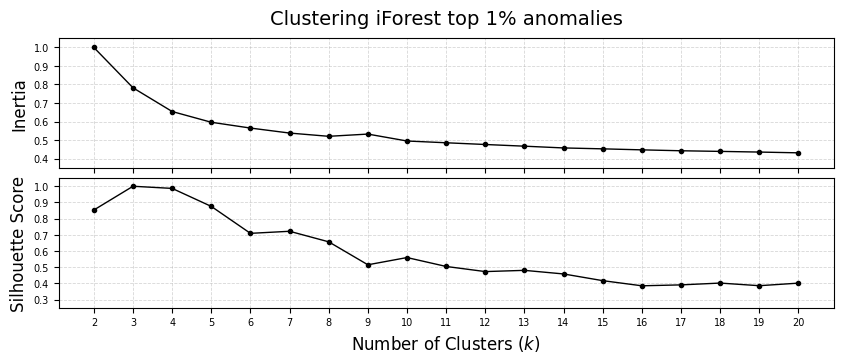

## Train and save

In [ ]:
# ```python
start_time = time.perf_counter()

X = weights_dict["norm_unique_weights"]
kmeans_model = KMeans(n_clusters=n_clusters, random_state=0).fit(X)
end_time = time.perf_counter()
print(f"train time: {end_time - start_time:.2f} seconds")

# save model
joblib.dump(kmeans_model, f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
# ```

# ```python
# train time: 0.17 seconds
# [
# '/home/elom/phd/code/clustering/bin_03/iforest/kmeans_4_clusters_343_segments.joblib'
# ]
# ```

train time: 0.17 seconds


['/home/elom/phd/code/clustering/bin_03/iforest/kmeans_4_clusters_343_segments.joblib']

## Save metadata

In [13]:
# ```python
kmeans_model = joblib.load(f"{kmeans_model_dir}/{kmeans_model_name}.joblib")

cluster_meta_df = meta_with_ratios_df.loc[specobjids_arr].copy()
cluster_meta_df["cluster"] = kmeans_model.labels_

cluster_meta_df.to_csv(f"{kmeans_model_dir}/metadata.csv.gz", compression="gzip")
# ```

# Clusters metadata

In [14]:
X = weights_dict["norm_unique_weights"]
X.shape

(1819, 343)

In [ ]:
kmeans_model = joblib.load(f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
cluster_labels = kmeans_model.labels_

# get spectra and weights per cluster
spectra_cluster_dict, weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=weights_dict["norm_weights"],
    print_n_clusters=True,
)

weights_dict["spectra_cluster_dict"] = spectra_cluster_dict
weights_dict["weights_cluster_dict"] = weights_cluster_dict

_, unique_weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=weights_dict["norm_unique_weights"],
    print_n_clusters=False,
)

weights_dict["unique_weights_cluster_dict"] = unique_weights_cluster_dict
centroids = kmeans_model.cluster_centers_
weights_dict["centroids"] = centroids

# 0;508
# 1;686
# 2;357
# 3;268

0;508
1;686
2;357
3;268


In [16]:
cluster_meta_df = pd.read_csv(
    f"{kmeans_model_dir}/metadata.csv.gz", index_col="specobjid"
)
cluster_meta_df.shape

(1819, 52)

# Avg Spec & Explanations

In [17]:
lw = 0.75
for label, centroid in enumerate(weights_dict["centroids"]):

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(20, 7),
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    centroid = clustering.expand_weights_per_segments(
        centroid.reshape(1, -1),
        wave_nm.size,
        n_segments,
    )

    centroid = centroid.reshape(-1)
    avg_spectrum = weights_dict["spectra_cluster_dict"][label].mean(axis=0)

    axs[0].plot(
        wave_nm, avg_spectrum, color="black", label="Average spectrum", linewidth=lw
    )
    axs[0].legend()
    # weights
    axs[1].plot(
        wave_nm, centroid, color="black", label="Average explanation", linewidth=lw
    )
    axs[1].legend()
    # set limits
    axs[1].set_ylim(0, 1.1)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label}",
        fontsize=12,
    )

    plot_name = f"avg_spec_centroid_{label}"

    save_to = f"{kmeans_model_dir}/avg_spec_centroids"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

## Top ranked anomalies per cluster

In [22]:
cluster_id = 0

mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask].copy()

spectra = anomalies_arr[mask]
norm_weights = weights_dict["norm_weights"][mask]

plot_top_ranked_explanations(
    cluster_id=cluster_id,
    metadata_df=metadata_df,
    spectra=spectra,
    norm_weights=norm_weights,
    wave=wave_nm,
    kmeans_model_dir=kmeans_model_dir,
    donwload_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
)

Number of anomalies in cluster 0: 508
Explanation for anomaly rank 1
Explanation for anomaly rank 2
Explanation for anomaly rank 3
Explanation for anomaly rank 4
Explanation for anomaly rank 5
Explanation for anomaly rank 6
Explanation for anomaly rank 7
Explanation for anomaly rank 8
Explanation for anomaly rank 9
Explanation for anomaly rank 10
Explanation for anomaly rank 11
Explanation for anomaly rank 12
Explanation for anomaly rank 13
Explanation for anomaly rank 14
Explanation for anomaly rank 15
Explanation for anomaly rank 16
Explanation for anomaly rank 17
Explanation for anomaly rank 18
Explanation for anomaly rank 19
Explanation for anomaly rank 20
Explanation for anomaly rank 21


# Line ratios

In [23]:
cluster_meta_df[SDSS_NEBULAR_LINES_RATIOS_NAMES].describe()

,balmer_decrement,nii_to_halpha,oiii_to_hbeta,oiii_to_oii,sii_to_halpha,sii_density_ratio,o3n2_index
count,1785.000000,1780.000000,1779.000000,1.319000e+03,1.702000e+03,1.706000e+03,1758.000000
mean,83.393615,0.355319,3.256051,2.400250e+00,8.601629e+04,1.391459e+00,0.848145
std,3334.929230,0.776495,21.853361,8.136999e+00,3.548616e+06,1.208053e+00,0.698301
min,0.036110,0.000004,0.048726,1.103384e-08,7.499223e-06,8.169128e-10,-1.176081
25%,3.273033,0.112121,0.788741,8.250245e-01,2.028204e-01,1.249673e+00,0.272622
50%,3.593491,0.205114,1.955763,1.500842e+00,2.424836e-01,1.349633e+00,0.981677
75%,4.272312,0.423180,3.019296,2.365022e+00,2.851698e-01,1.405228e+00,1.374862
max,140901.290334,22.009314,816.104492,2.589991e+02,1.463992e+08,3.274728e+01,5.525173


In [24]:
# Compute deciles (10th to 90th percentiles) for each column
n_delta = 0.05
deciles = np.arange(n_delta, 1.01, n_delta)
decile_df = cluster_meta_df[SDSS_NEBULAR_LINES_RATIOS_NAMES].quantile(q=deciles).T

decile_df.columns = [f"{int(q * 100)}th" for q in deciles]
decile_df.round(4)

,5th,10th,15th,20th,25th,30th,35th,40th,45th,50th,55th,60th,65th,70th,75th,80th,85th,90th,95th,100th
balmer_decrement,2.7846,3.0310,3.1240,3.2040,3.2730,3.3350,3.3910,3.4507,3.5130,3.5935,3.6710,3.7787,3.9122,4.0527,4.2723,4.5792,4.8516,5.2681,5.9827,1.409013e+05
nii_to_halpha,0.0596,0.0737,0.0865,0.0997,0.1121,0.1255,0.1414,0.1586,0.1769,0.2051,0.2506,0.3082,0.3486,0.3868,0.4232,0.4798,0.5611,0.6872,0.9243,2.200930e+01
oiii_to_hbeta,0.2183,0.3084,0.4151,0.5812,0.7887,1.0427,1.3221,1.5668,1.7646,1.9558,2.1620,2.3724,2.5835,2.7558,3.0193,3.2935,3.7052,4.3026,7.1414,8.161045e+02
oiii_to_oii,0.4104,0.5205,0.5830,0.6637,0.8250,0.9540,1.0968,1.2270,1.3607,1.5008,1.6301,1.7987,1.9362,2.1120,2.3650,2.6620,3.1910,4.1458,6.8551,2.589991e+02
sii_to_halpha,0.1447,0.1652,0.1818,0.1936,0.2028,0.2124,0.2204,0.2273,0.2349,0.2425,0.2493,0.2573,0.2652,0.2742,0.2852,0.2981,0.3180,0.3807,0.5287,1.463992e+08
sii_density_ratio,1.0204,1.1063,1.1642,1.2136,1.2497,1.2747,1.3000,1.3202,1.3356,1.3496,1.3626,1.3725,1.3824,1.3948,1.4052,1.4190,1.4334,1.4595,1.5117,3.274730e+01
o3n2_index,-0.3284,-0.1507,-0.0117,0.1194,0.2726,0.4342,0.5957,0.7801,0.8800,0.9817,1.0527,1.1372,1.2110,1.2921,1.3749,1.4532,1.5489,1.6648,1.8074,5.525200e+00


# Median line ratios

In [25]:
median_cluster_ratios_df = pd.DataFrame(
    index=range(0, n_clusters),
    columns=SDSS_NEBULAR_LINES_RATIOS_NAMES,
)
for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id

    median_cluster_ratios_df.loc[cluster_id, "balmer_decrement"] = np.nanmedian(
        cluster_meta_df.loc[mask, "balmer_decrement"]
    )
    median_cluster_ratios_df.loc[cluster_id, "nii_to_halpha"] = np.nanmedian(
        cluster_meta_df.loc[mask, "nii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_hbeta"] = np.nanmedian(
        cluster_meta_df.loc[mask, "oiii_to_hbeta"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_oii"] = np.nanmedian(
        cluster_meta_df.loc[mask, "oiii_to_oii"]
    )
    median_cluster_ratios_df.loc[cluster_id, "o3n2_index"] = np.nanmedian(
        cluster_meta_df.loc[mask, "o3n2_index"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_to_halpha"] = np.nanmedian(
        cluster_meta_df.loc[mask, "sii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_density_ratio"] = np.nanmedian(
        cluster_meta_df.loc[mask, "sii_density_ratio"]
    )
# map col name by replacing the '_' with ' ' for better readability
median_cluster_ratios_df.columns = [
    col.replace("_", " ") for col in median_cluster_ratios_df.columns
]

median_cluster_ratios_df.to_clipboard(excel=True, index=True)
median_cluster_ratios_df

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
0,3.370117,0.110991,3.1978,2.370363,0.219402,1.368398,1.378694
1,4.21983,0.359637,0.688845,0.796173,0.249473,1.295995,0.237381
2,3.426871,0.154179,2.159106,1.606102,0.233839,1.372466,1.15159
3,3.314825,0.479844,1.728548,1.262998,0.321072,1.412777,0.456783


In [26]:
percentiles = np.arange(0.45, 0.55, 0.01)
ratios_percentiles_df = cluster_meta_df[
    SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# ].quantile(q=percentiles)

# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,46th,47th,48th,49th,50th,51th,52th,53th,54th,55th
balmer decrement,3.513030,3.529303,3.542035,3.559980,3.576018,3.593491,3.605222,3.620148,3.632095,3.648950,3.671016
nii to halpha,0.176868,0.180922,0.185903,0.191139,0.199140,0.205114,0.215082,0.222334,0.232870,0.243185,0.250580
oiii to hbeta,1.764615,1.820175,1.848936,1.881008,1.916143,1.955763,1.990199,2.027579,2.069892,2.114308,2.161970
oiii to oii,1.360680,1.390791,1.414918,1.457047,1.478662,1.500842,1.523128,1.538747,1.564692,1.597455,1.630072
sii to halpha,0.234918,0.237101,0.238741,0.239568,0.240709,0.242484,0.243541,0.244822,0.246046,0.247548,0.249283
sii density ratio,1.335578,1.339280,1.341194,1.344813,1.347330,1.349633,1.352294,1.355716,1.357662,1.359626,1.362563
o3n2 index,0.880025,0.906283,0.925037,0.950213,0.967373,0.981677,0.996877,1.010276,1.025463,1.035775,1.052709


## Cluster 0 ratios percentiles

In [27]:
cluster_mask = cluster_meta_df["cluster"] == 0
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer decrement,3.279531,3.334899,3.370117,3.405894,3.460039
nii to halpha,0.095960,0.103414,0.110991,0.123406,0.134599
oiii to hbeta,2.870261,3.034076,3.197800,3.341132,3.547131
oiii to oii,2.077531,2.172750,2.370363,2.539626,2.852365
sii to halpha,0.201066,0.209512,0.219402,0.228034,0.237227
sii density ratio,1.346466,1.357794,1.368398,1.376392,1.386218
o3n2 index,1.271344,1.321151,1.378694,1.437951,1.479581


## Cluster 1 ratios percentiles

In [28]:
cluster_mask = cluster_meta_df["cluster"] == 1
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer decrement,3.984838,4.093321,4.219830,4.401775,4.544532
nii to halpha,0.324730,0.343090,0.359637,0.376430,0.396044
oiii to hbeta,0.496097,0.576080,0.688845,0.807851,0.963379
oiii to oii,0.662576,0.719554,0.796173,0.886220,0.972900
sii to halpha,0.239429,0.243929,0.249473,0.254827,0.260916
sii density ratio,1.258378,1.275753,1.295995,1.314395,1.327707
o3n2 index,0.088444,0.151481,0.237381,0.329717,0.431085


## Cluster 2 percentiles

In [29]:
cluster_mask = cluster_meta_df["cluster"] == 2
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer decrement,3.374184,3.407615,3.426871,3.459629,3.499448
nii to halpha,0.133776,0.144489,0.154179,0.159999,0.168888
oiii to hbeta,1.892050,2.022352,2.159106,2.296373,2.416936
oiii to oii,1.413412,1.485913,1.606102,1.792153,1.882032
sii to halpha,0.221296,0.226806,0.233839,0.240377,0.246619
sii density ratio,1.354688,1.364105,1.372466,1.380093,1.388815
o3n2 index,1.042587,1.099536,1.151590,1.192151,1.255674


## Cluster 3 ratios percentiles

In [30]:
cluster_mask = cluster_meta_df["cluster"] == 3
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer decrement,3.123446,3.197812,3.314825,3.475565,3.615817
nii to halpha,0.336229,0.387581,0.479844,0.540058,0.588544
oiii to hbeta,1.249537,1.509255,1.728548,1.878475,1.980726
oiii to oii,0.969904,1.069034,1.262998,1.342202,1.499117
sii to halpha,0.282039,0.301689,0.321072,0.353923,0.395535
sii density ratio,1.380721,1.397725,1.412777,1.423779,1.447354
o3n2 index,0.313723,0.380845,0.456783,0.561975,0.711740


# Redshift Analysis

In [32]:
z_dict = {"cluster": [], "z_min": [], "z_max": [], "z_mean": [], "z_median": []}

for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id
    z = cluster_meta_df["z"].loc[mask].values

    z_dict["cluster"].append(cluster_id)
    z_dict["z_min"].append(np.min(z))
    z_dict["z_max"].append(np.max(z))
    z_dict["z_mean"].append(np.mean(z))
    z_dict["z_median"].append(np.median(z))
z_df = pd.DataFrame(z_dict)
z_df

,cluster,z_min,z_max,z_mean,z_median
0,0,0.010132,0.234753,0.049081,0.036922
1,1,0.010093,0.263567,0.055137,0.038531
2,2,0.017820,0.215538,0.056242,0.041868
3,3,0.010838,0.245802,0.072727,0.065605


In [33]:
low_wave, upper_wave = 5_565, 5_590
z_df["lower_wave_min"] = low_wave / (1 + z_df["z_min"])
z_df["upper_wave_min"] = upper_wave / (1 + z_df["z_min"])
z_df["lower_wave_max"] = low_wave / (1 + z_df["z_max"])
z_df["upper_wave_max"] = upper_wave / (1 + z_df["z_max"])
z_df["lower_wave_mean"] = low_wave / (1 + z_df["z_mean"])
z_df["upper_wave_mean"] = upper_wave / (1 + z_df["z_mean"])
z_df["lower_wave_median"] = low_wave / (1 + z_df["z_median"])
z_df["upper_wave_median"] = upper_wave / (1 + z_df["z_median"])
z_df

,cluster,z_min,z_max,z_mean,z_median,lower_wave_min,upper_wave_min,lower_wave_max,upper_wave_max,lower_wave_mean,upper_wave_mean,lower_wave_median,upper_wave_median
0,0,0.010132,0.234753,0.049081,0.036922,5509.182778,5533.932027,4506.975729,4527.222700,5304.644238,5328.474625,5366.845362,5390.955180
1,1,0.010093,0.263567,0.055137,0.038531,5509.396417,5534.146625,4404.197893,4423.983149,5274.195394,5297.888994,5358.528141,5382.600594
2,2,0.017820,0.215538,0.056242,0.041868,5467.565844,5492.128135,4578.218556,4598.785575,5268.679058,5292.347876,5341.369158,5365.364528
3,3,0.010838,0.245802,0.072727,0.065605,5505.334070,5530.066029,4467.000904,4487.068293,5187.713522,5211.018615,5222.383592,5245.844435
